In [26]:
!pip install scikit-optimize
!pip install xgboost
!pip install lightgbm


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [29]:
dfd = pd.read_csv("day.csv")
dfh = pd.read_csv("hour.csv")

In [30]:
dfd.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [31]:
dfd.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [32]:
dfh.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [33]:
dfh.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [34]:
def evaluate_models(df, label="Dataset"):
    """
    Evaluate multiple regression models using TRAINING + TESTING metrics.
    Returns:
    1. Performance table
    2. y_test
    3. Dictionary of test predictions for each model
    """

    X = df.drop("cnt", axis=1)
    y = df["cnt"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
        "Lasso Regression": Lasso(alpha=0.001),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
        "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
        "SVR (RBF Kernel)": SVR(kernel="rbf", C=100, epsilon=0.1),
        "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=64,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            force_col_wise=True,
            verbose=-1
        )
    }

    results = []
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

        predictions[name] = pred_test

        results.append([
            name,
            np.sqrt(mean_squared_error(y_train, pred_train)),
            np.sqrt(mean_squared_error(y_test, pred_test)),
            mean_absolute_error(y_train, pred_train),
            mean_absolute_error(y_test, pred_test),
            r2_score(y_train, pred_train),
            r2_score(y_test, pred_test)
        ])

    df_results = pd.DataFrame(
        results,
        columns=[
            "Model",
            "Train RMSE", "Test RMSE",
            "Train MAE", "Test MAE",
            "Train R²", "Test R²"
        ]
    )

    print(f"===== Detailed Performance Comparison: {label} =====")
    print(df_results)

    return df_results, y_test, predictions


In [35]:
import matplotlib.pyplot as plt
import math

def plot_all_models(y_test, preds_dict, title_prefix="Day Dataset", n_samples=200):
    models = list(preds_dict.keys())
    n_models = len(models)

    cols = 2
    rows = math.ceil(n_models / cols)

    # Take only first n samples
    y_plot = y_test.values[:n_samples]

    plt.figure(figsize=(14, rows * 3))

    for i, model in enumerate(models, 1):
        plt.subplot(rows, cols, i)
        plt.plot(y_plot, label="Actual", color="black", linewidth=2)
        plt.plot(preds_dict[model][:n_samples], label="Predicted", alpha=0.8)
        plt.title(model)
        plt.xlabel("Sample Index")
        plt.ylabel("cnt")
        plt.legend()

    plt.suptitle(
        f"Actual vs Predicted — {title_prefix} (First {n_samples} Samples)",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [36]:
if "dteday" in dfd.columns:
    dfd = dfd.drop("dteday", axis=1)

if "dteday" in dfh.columns:
    dfh = dfh.drop("dteday", axis=1)

In [37]:
results_day_df, y_day_test, preds_day = evaluate_models(dfd, "Day Dataset")

===== Detailed Performance Comparison: Day Dataset =====
               Model    Train RMSE     Test RMSE     Train MAE      Test MAE  Train R²   Test R²
0  Linear Regression  7.986706e-13  8.616079e-13  6.025986e-13  6.574212e-13  1.000000  1.000000
1   Ridge Regression  4.326316e-06  3.754317e-06  3.108285e-06  2.972212e-06  1.000000  1.000000
2   Lasso Regression  1.194598e-01  1.238833e-01  1.033086e-01  1.077624e-01  1.000000  1.000000
3         ElasticNet  2.189579e-02  2.287988e-02  1.888970e-02  1.982664e-02  1.000000  1.000000
4      KNN Regressor  7.555686e+01  1.003691e+02  5.036849e+01  5.777415e+01  0.998443  0.997488
5   SVR (RBF Kernel)  1.990572e+02  1.981566e+02  1.113708e+02  1.126243e+02  0.989191  0.990208
6      Random Forest  4.685489e+01  1.025527e+02  2.939856e+01  6.495444e+01  0.999401  0.997377
7  Gradient Boosting  6.205127e+01  1.034349e+02  4.795057e+01  7.306240e+01  0.998950  0.997332
8            XGBoost  8.277726e+00  1.431778e+02  6.208045e+00  9.1633

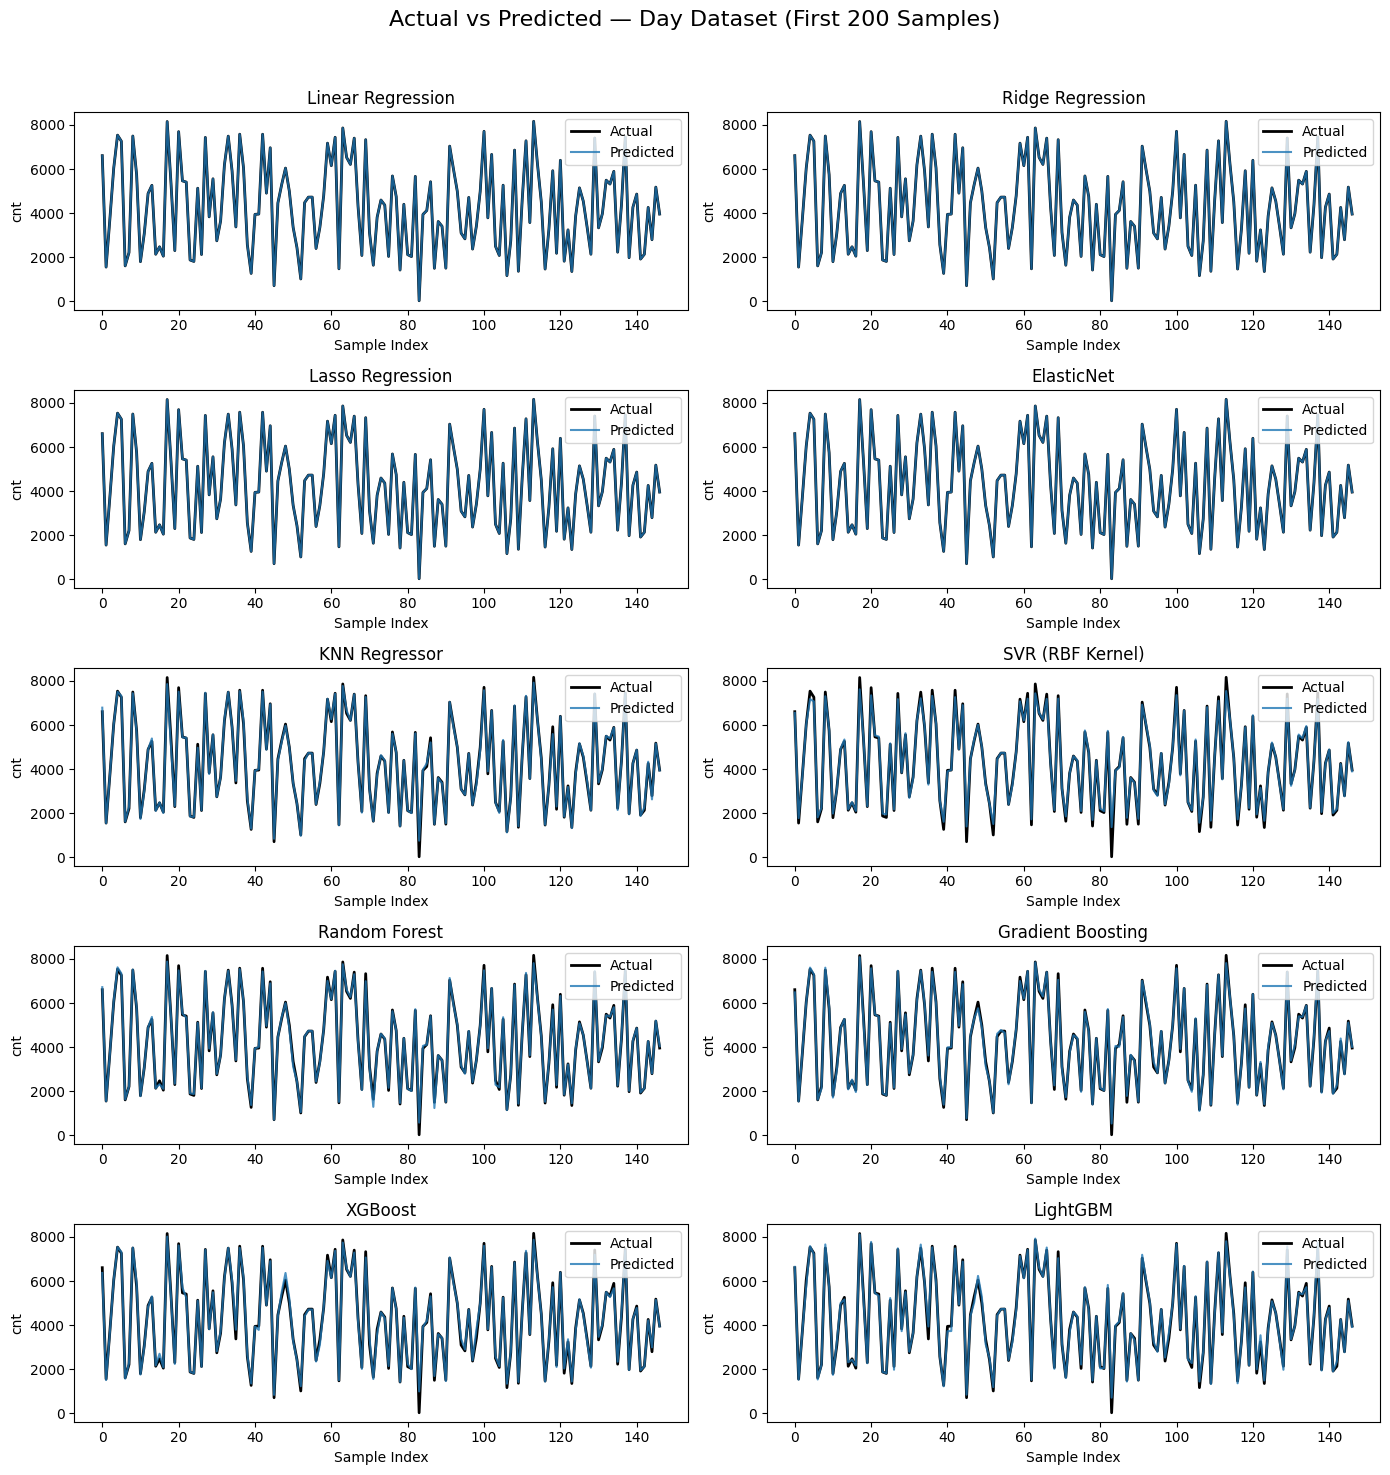

In [38]:
plot_all_models(y_day_test, preds_day, "Day Dataset", n_samples=200)

In [39]:
results_hour_df, y_hour_test, preds_hour = evaluate_models(dfh, "Hour Dataset")

===== Detailed Performance Comparison: Hour Dataset =====
               Model    Train RMSE     Test RMSE     Train MAE      Test MAE  Train R²   Test R²
0  Linear Regression  2.883988e-11  2.862396e-11  2.497117e-11  2.469898e-11  1.000000  1.000000
1   Ridge Regression  1.974575e-06  1.904954e-06  1.319092e-06  1.270093e-06  1.000000  1.000000
2   Lasso Regression  2.311584e-04  2.270093e-04  1.806129e-04  1.776296e-04  1.000000  1.000000
3         ElasticNet  8.415552e-05  8.122501e-05  5.501294e-05  5.316501e-05  1.000000  1.000000
4      KNN Regressor  1.253546e+01  1.637031e+01  8.636007e+00  1.108377e+01  0.995267  0.991537
5   SVR (RBF Kernel)  2.484861e+01  2.383332e+01  1.575602e+01  1.520229e+01  0.981403  0.982062
6      Random Forest  1.030471e+00  2.697276e+00  3.533822e-01  9.212342e-01  0.999968  0.999770
7  Gradient Boosting  4.655113e+00  5.235476e+00  3.060809e+00  3.303406e+00  0.999347  0.999134
8            XGBoost  2.868293e+00  4.542584e+00  1.912132e+00  2.603

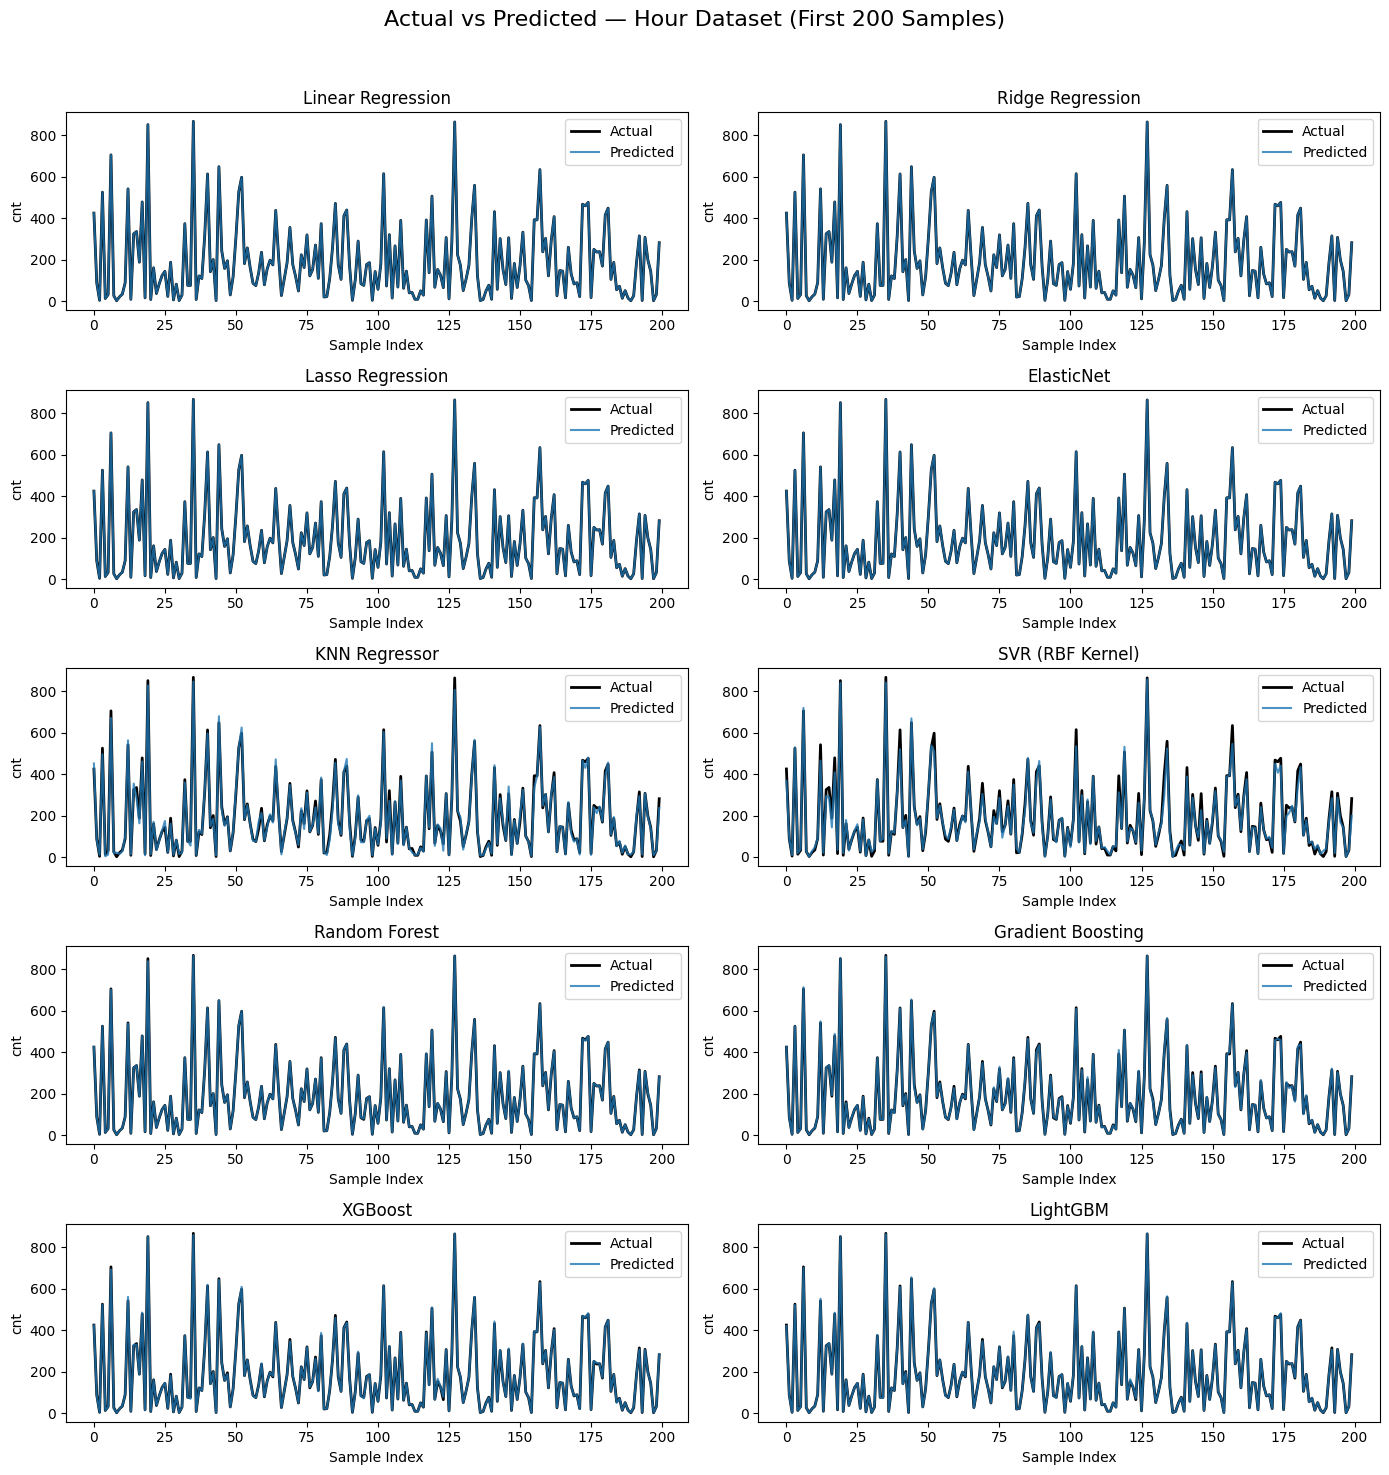

In [40]:
plot_all_models(y_hour_test, preds_hour, "Hour Dataset", n_samples=200)

In [41]:
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=5000),
    "ElasticNet": ElasticNet(max_iter=5000),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42, verbosity=-1)
}

In [42]:
grid_params = {
    "Ridge": {"alpha": [0.01, 0.1, 1, 10]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1]},
    "ElasticNet": {"alpha": [0.01, 0.1], "l1_ratio": [0.3, 0.5, 0.7]},
    "KNN": {"n_neighbors": [3, 5, 7]},
    "SVR": {"C": [1, 10], "gamma": ["scale", "auto"]},
    "Random Forest": {"n_estimators": [200, 400], "max_depth": [None, 20]},
    "Gradient Boosting": {"n_estimators": [200, 400], "learning_rate": [0.05, 0.1]},
    "XGBoost": {"n_estimators": [200, 400], "max_depth": [4, 6]},
    "LightGBM": {"n_estimators": [200, 400], "num_leaves": [31, 63]}
}

In [43]:
random_params = {
    "Ridge": {"alpha": np.logspace(-3, 2, 20)},
    "Lasso": {"alpha": np.logspace(-4, 1, 20)},
    "ElasticNet": {"alpha": np.logspace(-3, 1, 10), "l1_ratio": np.linspace(0.1, 0.9, 5)},
    "KNN": {"n_neighbors": range(3, 15)},
    "SVR": {"C": np.logspace(0, 3, 20)},
    "Random Forest": {"n_estimators": range(200, 800), "max_depth": range(5, 40)},
    "Gradient Boosting": {"n_estimators": range(200, 800), "learning_rate": np.linspace(0.01, 0.2, 10)},
    "XGBoost": {"n_estimators": range(200, 800), "max_depth": range(3, 10)},
    "LightGBM": {"n_estimators": range(200, 800), "num_leaves": range(20, 100)}
}

In [44]:
bayes_params = {
    "Ridge": {"alpha": Real(1e-3, 100)},
    "Lasso": {"alpha": Real(1e-4, 10)},
    "ElasticNet": {"alpha": Real(1e-3, 10), "l1_ratio": Real(0.1, 0.9)},
    "KNN": {"n_neighbors": Integer(3, 20)},
    "SVR": {"C": Real(0.1, 100)},
    "Random Forest": {"n_estimators": Integer(200, 800), "max_depth": Integer(5, 40)},
    "Gradient Boosting": {"n_estimators": Integer(200, 800), "learning_rate": Real(0.01, 0.2)},
    "XGBoost": {"n_estimators": Integer(200, 800), "max_depth": Integer(3, 10)},
    "LightGBM": {"n_estimators": Integer(200, 800), "num_leaves": Integer(20, 100)}
}

In [45]:
def evaluate(model, X_train, X_test, y_train, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "Train RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
        "Train MAE": mean_absolute_error(y_train, pred_train),
        "Test MAE": mean_absolute_error(y_test, pred_test),
        "Train R²": r2_score(y_train, pred_train),
        "Test R²": r2_score(y_test, pred_test),
    }

In [46]:
def tune_all_models_with_methods(df, label="Dataset"):
    X = df.drop("cnt", axis=1)
    y = df["cnt"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    final_results = []
    best_models = {}

    for name, base_model in models.items():
        print(f"\n ****** {name} — {label} ******")

        tuning_strategies = []

        if name in grid_params:
            tuning_strategies.append((
                "Grid Search",
                GridSearchCV(base_model, grid_params[name], cv=3, scoring="r2", n_jobs=-1)
            ))

        if name in random_params:
            tuning_strategies.append((
                "Random Search",
                RandomizedSearchCV(
                    base_model,
                    random_params[name],
                    n_iter=15,
                    cv=3,
                    scoring="r2",
                    n_jobs=-1,
                    random_state=42
                )
            ))

        if name in bayes_params:
            tuning_strategies.append((
                "Bayesian Optimization",
                BayesSearchCV(
                    base_model,
                    bayes_params[name],
                    n_iter=20,
                    cv=3,
                    scoring="r2",
                    n_jobs=-1,
                    random_state=42
                )
            ))

        for method_name, search in tuning_strategies:
            search.fit(X_train, y_train)
            best_model = search.best_estimator_

            # Save trained model
            best_models[(name, method_name)] = best_model

            metrics = evaluate(best_model, X_train, X_test, y_train, y_test)

            final_results.append([
                name,
                method_name,
                metrics["Train RMSE"],
                metrics["Test RMSE"],
                metrics["Train MAE"],
                metrics["Test MAE"],
                metrics["Train R²"],
                metrics["Test R²"],
            ])

    results_df = pd.DataFrame(
        final_results,
        columns=[
            "Model", "Tuning Method",
            "Train RMSE", "Test RMSE",
            "Train MAE", "Test MAE",
            "Train R²", "Test R²"
        ]
    )

    return results_df, best_models

In [47]:
day_results, day_best_models = tune_all_models_with_methods(dfd, "Day Dataset")
day_results


 ****** Ridge — Day Dataset ******

 ****** Lasso — Day Dataset ******

 ****** ElasticNet — Day Dataset ******

 ****** KNN — Day Dataset ******

 ****** SVR — Day Dataset ******

 ****** Random Forest — Day Dataset ******

 ****** Gradient Boosting — Day Dataset ******

 ****** XGBoost — Day Dataset ******

 ****** LightGBM — Day Dataset ******


,Model,Tuning Method,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²
0,Ridge,Grid Search,4.521644e-08,3.886453e-08,3.262857e-08,3.067158e-08,1.000000,1.000000
1,Ridge,Random Search,4.523015e-09,3.887107e-09,3.264449e-09,3.067528e-09,1.000000,1.000000
2,Ridge,Bayesian Optimization,1.615974e-06,1.396009e-06,1.163026e-06,1.103276e-06,1.000000,1.000000
3,Lasso,Grid Search,6.198734e-04,5.712287e-04,4.866469e-04,4.406162e-04,1.000000,1.000000
4,Lasso,Random Search,1.530490e-04,1.468819e-04,1.192595e-04,1.132332e-04,1.000000,1.000000
5,Lasso,Bayesian Optimization,2.063796e-03,2.132061e-03,1.730004e-03,1.833118e-03,1.000000,1.000000
6,ElasticNet,Grid Search,9.654953e-04,8.764067e-04,7.591914e-04,6.814193e-04,1.000000,1.000000
7,ElasticNet,Random Search,4.526001e-04,4.158607e-04,3.554330e-04,3.211535e-04,1.000000,1.000000
8,ElasticNet,Bayesian Optimization,2.895760e-03,2.807108e-03,2.351302e-03,2.295832e-03,1.000000,1.000000
9,KNN,Grid Search,7.555686e+01,1.003691e+02,5.036849e+01,5.777415e+01,0.998443,0.997488


In [48]:
hour_results, hour_best_models = tune_all_models_with_methods(dfh, "Hour Dataset")
hour_results


 ****** Ridge — Hour Dataset ******

 ****** Lasso — Hour Dataset ******

 ****** ElasticNet — Hour Dataset ******

 ****** KNN — Hour Dataset ******

 ****** SVR — Hour Dataset ******

 ****** Random Forest — Hour Dataset ******

 ****** Gradient Boosting — Hour Dataset ******

 ****** XGBoost — Hour Dataset ******

 ****** LightGBM — Hour Dataset ******


,Model,Tuning Method,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²
0,Ridge,Grid Search,1.975920e-08,1.906208e-08,1.320300e-08,1.271208e-08,1.000000,1.000000
1,Ridge,Random Search,1.975977e-09,1.906263e-09,1.320345e-09,1.271251e-09,1.000000,1.000000
2,Ridge,Bayesian Optimization,7.191109e-07,6.937463e-07,4.804660e-07,4.626078e-07,1.000000,1.000000
3,Lasso,Grid Search,2.311584e-04,2.270093e-04,1.806129e-04,1.776296e-04,1.000000,1.000000
4,Lasso,Random Search,1.007799e-04,1.014590e-04,9.104797e-05,9.158639e-05,1.000000,1.000000
5,Lasso,Bayesian Optimization,8.617883e-04,8.306517e-04,5.670147e-04,5.475662e-04,1.000000,1.000000
6,ElasticNet,Grid Search,5.122226e-04,4.932456e-04,3.255946e-04,3.144885e-04,1.000000,1.000000
7,ElasticNet,Random Search,2.349544e-04,2.328334e-04,1.927165e-04,1.916034e-04,1.000000,1.000000
8,ElasticNet,Bayesian Optimization,6.661066e-04,6.450626e-04,4.707647e-04,4.558947e-04,1.000000,1.000000
9,KNN,Grid Search,1.030795e+01,1.557689e+01,7.202666e+00,1.084129e+01,0.996800,0.992337


In [49]:
def get_best_model(results_df, best_models, overfit_penalty=0.5):
    """
    Selects best model based on:
    - High Test R²
    - Low Train–Test R² gap (generalization)
    - Production readiness
    """

    df = results_df.copy()

    # Overfitting gap
    df["Overfit_Gap"] = abs(df["Train R²"] - df["Test R²"])

    # Final production score
    df["Final_Score"] = df["Test R²"] - overfit_penalty * df["Overfit_Gap"]

    # Sort by final score
    best_row = df.sort_values("Final_Score", ascending=False).iloc[0]

    model_name = best_row["Model"]
    tuning_method = best_row["Tuning Method"]
    best_model = best_models[(model_name, tuning_method)]

    print("Model Selection Reasoning")
    print(f"Best Model      : {model_name}")
    print(f"Tuning Method   : {tuning_method}")
    print(f"Test R²         : {best_row['Test R²']:.4f}")
    print(f"Overfit Gap     : {best_row['Overfit_Gap']:.4f}")
    print(f"Final Score     : {best_row['Final_Score']:.4f}")

    return model_name, tuning_method, best_model

In [50]:
def recursive_forecast_day(model, input_df, steps):
    preds = []
    current_input = input_df.copy()

    for i in range(steps):
        pred = model.predict(current_input)[0]
        preds.append(pred)

        # Example: increment month safely
        if "mnth" in current_input.columns:
            current_input["mnth"] = (current_input["mnth"] % 12) + 1

        # Rotate weekday
        if "weekday" in current_input.columns:
            current_input["weekday"] = (current_input["weekday"] + 1) % 7

    return preds

In [51]:
day_feature_cols = [
    "season", "mnth", "holiday", "weekday",
    "workingday", "weathersit", "temp",
    "atemp", "hum", "windspeed"
]

In [52]:
DAY_NAMES = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

In [53]:
def predict_next_6_days(model, user_input, feature_cols):
    """
    Predict next 6 days with real weekday names, without index in output.
    """

    input_df = pd.DataFrame([user_input])[feature_cols]

    preds = recursive_forecast_day(
        model=model,
        input_df=input_df,
        steps=6
    )

    start_weekday = user_input["weekday"]  # 0=Sun, 6=Sat

    day_labels = [
        DAY_NAMES[(start_weekday + i) % 7] for i in range(0, 6)
    ]

    result_df = pd.DataFrame({
        "Day": day_labels,
        "Predicted cnt": np.round(preds, 2)
    })

    # Optional: remove index when printing or exporting
    result_df.index = [""] * len(result_df)

    return result_df

In [54]:
day_input = {
    "season": 1,
    "mnth": 1,
    "holiday": 0,
    "weekday": 2,
    "workingday": 1,
    "weathersit": 2,
    "temp": 0.344167,
    "atemp": 0.363625,
    "hum": 0.805833,
    "windspeed": 0.160446
}

In [ ]:
model_name, tuning_method, best_day_model = get_best_model(
    day_results, day_best_models
)


print("\nDaily Forecast")
print(
    predict_next_6_days(
        best_day_model,
        day_input,
        day_feature_cols
    )
)

Model Selection Reasoning
Best Model      : Gradient Boosting
Tuning Method   : Bayesian Optimization
Test R²         : 0.6499
Overfit Gap     : 0.1070
Final Score     : 0.5964

Daily Forecast
  Day  Predicted cnt
  Tue        2506.80
  Wed        2605.12
  Thu        2605.12
  Fri        2639.28
  Sat        2660.23
  Sun        2498.83

In [ ]:
hour_feature_cols = [
    "season", "mnth", "hr", "holiday", "weekday",
    "workingday", "weathersit", "temp",
    "atemp", "hum", "windspeed"
]

In [ ]:
def recursive_forecast_hour(model, input_df, steps):
    preds = []
    current = input_df.copy()

    for _ in range(steps):
        pred = model.predict(current)[0]
        preds.append(pred)

        # increment hour safely
        current["hr"] = (current["hr"] + 1) % 24

        # update weekday if day rolls over
        if current["hr"].iloc[0] == 0:
            current["weekday"] = (current["weekday"] + 1) % 7

    return preds

In [ ]:
def format_hour(hour):
    if hour == 0:
        return "12 AM"
    elif hour < 12:
        return f"{hour} AM"
    elif hour == 12:
        return "12 PM"
    else:
        return f"{hour - 12} PM"

In [ ]:
def predict_next_6_hours(model, user_input, feature_cols):
    """
    Predict next 6 hours with real clock time labels, without index in output.
    """

    df = pd.DataFrame([user_input])[feature_cols]

    preds = recursive_forecast_hour(
        model=model,
        input_df=df,
        steps=6
    )

    start_hour = user_input["hr"]

    hour_labels = [
        format_hour((start_hour + i) % 24) for i in range(0, 6)
    ]

    result_df = pd.DataFrame({
        "Time": hour_labels,
        "Predicted cnt": np.round(preds, 2)
    })

    # Remove index for display
    result_df.index = [""] * len(result_df)

    return result_df

In [ ]:
hour_input = {
    "season": 1,
    "mnth": 1,
    "hr": 10,
    "holiday": 0,
    "weekday": 2,
    "workingday": 1,
    "weathersit": 1,
    "temp": 0.24,
    "atemp": 0.2879,
    "hum": 0.81,
    "windspeed": 0.00
}

In [ ]:
model_name, tuning_method, best_hour_model = get_best_model(
    hour_results, hour_best_models
)

print("\nHourly Forecast")
print(
    predict_next_6_hours(
        best_hour_model,
        hour_input,
        hour_feature_cols
    )
)

Model Selection Reasoning
Best Model      : LightGBM
Tuning Method   : Bayesian Optimization
Test R²         : 0.8892
Overfit Gap     : 0.0712
Final Score     : 0.8536

Hourly Forecast
   Time  Predicted cnt
  10 AM          78.43
  11 AM          69.66
  12 PM          81.14
   1 PM          64.53
   2 PM          45.44
   3 PM          55.70